In [1]:
import os

import introns
from collections import defaultdict
from Bio import SeqIO
from Bio.Seq import Seq
import numpy as np
import matplotlib.pyplot as plt
import csv

In [2]:
path="/mnt/archive/euglena_genomy/"
path2="/home/semik/projekty/noncanonical_introns/"

genom_EG=path+"gracilis/gracilis_dbg2olc.fasta"
geny_EG=path+"gracilis/gracilis_stringtie_strand_informed.gtf"

genom_EH=path+'hiemalis/hiemalis_rascaf.fasta'
geny_EH=path+'hiemalis/stringtie_strand_informed3.gtf'

genom_EL=path+'longa/longa_rascaf.fasta'
geny_EL=path+'longa/longa_stringtie_strand_informed.gtf'

genom_bugtest = '/home/semik/projekty/noncanonical_introns/bugtest.fasta'
geny_bugtest = '/home/semik/projekty/noncanonical_introns/bugtest.gtf'


In [ ]:
lista_gen=[]
for name, genome_eug, genes_eug in [("E.gracilis", genom_EG, geny_EG), ("E.hiemalis", genom_EH, geny_EH), ("E.longa", genom_EL, geny_EL)][:1]:
    print(name)
    genome,genes=introns.create_genes(genome_eug, genes_eug)
    print("vreating done")
    lista_gen.append((name,genome,genes))
    for nazwa, gene in list(genes.items()):
        print(nazwa)
        for intron in gene.introns:
            print("\tintron", len(intron.variations), intron.variations_struct_1, intron.variations_struct_2)


E.gracilis
genome read
genes read


In [ ]:
policzone_warianty=[]
gat=["wszystkie_introny_wersje_E.gracilis_25zmarginesami.fasta", "wszystkie_introny_wersje_E.hiemalis_25zmarginesami.fasta", "wszystkie_introny_wersje_E.longa_25zmarginesami.fasta"]
sztuczne=["generowane_introny_0.fasta", "generowane_introny_1.fasta", "generowane_introny_2.fasta", "generowane_introny_3.fasta", "generowane_introny_4.fasta"]
for plikfasta in gat:
    #count=0
    nr_variants=[]
    prev_d=None
    for line in open(plikfasta, "r").readlines():
        line=line.split(";")
        print(record)
        #d=int(line[1])
        '''if d==0:
            nr_variants.append(prev_d)
        prev_d = d
        count+=1
        #if count>100: break
    nr_variants.append(prev_d)
    nr_variants=nr_variants[1:]
    policzone_warianty.append(nr_variants)
    #print(nr_variants)'''

##### 

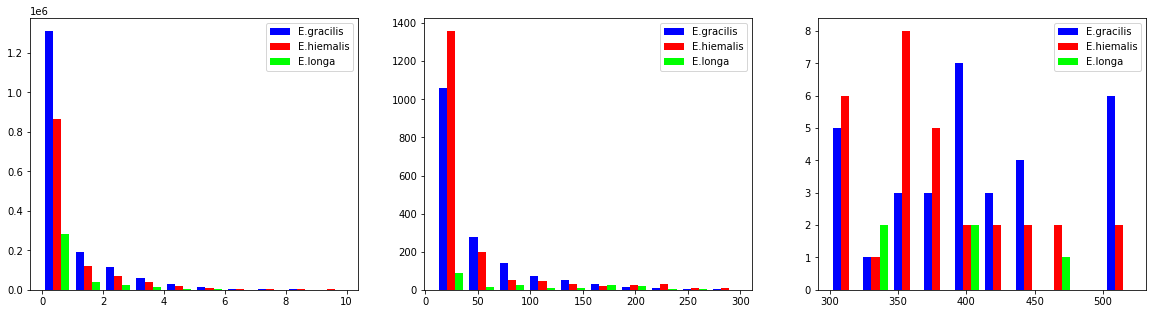

[439, 441, 447, 523, 523, 523, 523, 523, 523, 834]
[645, 727, 732, 732, 732, 1654, 1654, 1654, 1654, 1654]
[242, 249, 255, 263, 289, 335, 343, 393, 393, 461]


In [96]:
fig, ax = plt.subplots(1, 3, figsize=(20,5))
colors, gatunki = ['b', 'r', 'lime'], ["E.gracilis", "E.hiemalis", "E.longa"]

ax[0].hist(policzone_warianty, 10, histtype='bar', range=(0, 10), color=colors, label=colors)
ax[0].legend(ax[0].get_legend_handles_labels()[0], gatunki)
ax[1].hist(policzone_warianty, 10, histtype='bar', range=(10, 300), color=colors, label=colors)
ax[1].legend(ax[1].get_legend_handles_labels()[0], gatunki)
ax[2].hist(policzone_warianty, 10, histtype='bar', range=(300, 523), color=colors, label=colors)
ax[2].legend(ax[2].get_legend_handles_labels()[0], gatunki)

plt.show()

for gat in policzone_warianty:
    print(sorted(gat)[-10:])

In [47]:
def count_nconv(listaplikow, definicja_nonconv="seq", path=""):
    counts=[]
    dane_liczbowe=[]
    for plik in listaplikow:
    
        if plik.startswith("wszystkie_introny_wersje_E."):
            name=plik.split("_")[3]
        elif plik.startswith("generowane_introny_"):
            name=plik.split(".")[0]
        else:
            print("zla nazwa pliku")
            break
        
        plik=".".join(plik.split(".")[:-1])
        plikfasta, plikdbn=plik+".fasta", plik+".dbn"
        fasta=open(path+plikfasta, 'r').readlines()
        if fasta[0][0]==";": fasta=fasta[2:]
        dbn = open(path+plikdbn, 'r').readlines()
        
        fasta = [ x+y for x,y in zip(fasta[0::2], fasta[1::2]) ]
        dbn = [x+y+z for x,y,z in zip(dbn[0::3], dbn[1::3], dbn[2::3])]
        
        l=len(fasta) if len(fasta)==len(dbn) else None
        
        global conv_count, nconv_count, both_count, all_count, non_count
        conv_count, nconv_count, both_count, all_count, non_count = 0,0,0,0,0
        prev_var = [0, False, False] #wersja, kkonwencjonalny, niekonwencjonalny struktur

        def dodaj(prev_var):
            global conv_count, nconv_count, both_count, all_count, non_count
            var, conv_ver, nonconv_str=prev_var
            all_count+=1

            if nonconv_str and conv_ver: both_count+=1
            elif nonconv_str and not conv_ver: nconv_count+=1
            elif not nonconv_str and conv_ver: conv_count+=1
            else: non_count+=1
            
        for i in range(l):
            f, d = fasta[i].split("\n"), dbn[i].split("\n")
            if f[1] != d[1].replace("U", "T"):
                print("zle sekwencje")
                break
            
            var,conv_ver = f[0].split(";")[2:4]
            var=int(var)
            conv_ver=int(conv_ver)
            vienna = d[2].split(" ")[0]
            seq=d[1]
            
            if definicja_nonconv=="struct":
                '''warunki na niekonwencjonalne'''
                nonconv_str=0
                nazwa_pliku_png = "parowaniakons_przesuniecieo2_Rpoczkon"
                if not '(' in vienna[-25:-5] and not ')' in vienna[5:25]:
                    #if vienna.count('(', 0, 25)>5:
                    #    nonconv_str = 2
                    #    if seq[-5] in ["G", "A"]:
                    #        nonconv_str = 1
                    parowania_kons = vienna[8:11]=="(((" and vienna[-13:-10]==")))" #pozycje 4,5,6 (-8,-7,-6) -> indeksy 3,4,5 (-8,-7,-6) -> z 5 nt eksonu 8,9,10 (-13,-12,-11)
                    parowan_5 = vienna.count('(', 0, 25)>=5
                    przesuniecie = vienna[:8].count("(") == vienna[-10:].count(")")
                    puryna_pocz = seq[5] in ["G", "A"]
                    puryna_koniec =  seq[-5] in ["G", "A"]
                    pirymidyna_pocz = seq[4] in ["U", "C", "T"]
                    pirymidyna_koniec = seq[-4] in ["U", "C", "T"]
                    
                    zestaw_zasad = [parowania_kons, przesuniecie, pirymidyna_koniec, pirymidyna_pocz]
                    if False not in zestaw_zasad:
                        nonconv_str = 1
                    #nazwa_pliku_png = ''
                '''warunki na niekonwencjonalne'''
            elif definicja_nonconv=="seq":
                nonconv_str=f[0].split(";")[4]
                nonconv_str = int(nonconv_str) if nonconv_str != "False" else 0
                nazwa_pliku_png="liczby_intronow_seq"
            else:
                print("Zły typ definiowania niekonwencjonalnych: seq lub struct")
                return

            if var and var>prev_var[0]:
                if conv_ver>0: prev_var[1] = True
                if nonconv_str>0: prev_var[2] = True
                prev_var[0]=var
            elif not var:
                dodaj(prev_var)
                prev_var=[0,bool(conv_ver),bool(nonconv_str)]
        counts.append([name, conv_count/all_count, nconv_count/all_count, both_count/all_count, non_count/all_count, all_count])
        dane_liczbowe.append([name, conv_count, nconv_count, both_count, non_count, all_count])
    for count in counts:
        print(count, sum(count[1:5]))
    for i in dane_liczbowe:
        print(i)        
    return counts, dane_liczbowe, nazwa_pliku_png

def count_nconv_classes(listaplikow, path="", conv=False):
    counts=[]
    dane_liczbowe=[]
    for plik in listaplikow:
    
        if plik.startswith("wszystkie_introny_wersje_E."):
            name=plik.split("_")[3]
        elif plik.startswith("generowane_introny_"):
            name=plik.split(".")[0]
        else:
            print("zla nazwa pliku")
            break
        
        plik=".".join(plik.split(".")[:-1])
        plikfasta=plik+".fasta"
        fasta=open(path+plikfasta, 'r').readlines()
        if fasta[0][0]==";": fasta=fasta[2:]
        
        fasta = [ x+y for x,y in zip(fasta[0::2], fasta[1::2]) ]
        
        l=len(fasta)
        
        global nonconv_classes_count, all_count
        nonconv_classes_count = [0]*9 if conv==False else [0]*8
        all_count = 0
        prev_var = [0, 0] #wersja, klasa niekonwencjonalna

        def dodaj(prev_var):
            global nonconv_classes_count, all_count
            var, nonconv_ver=prev_var
            
            if nonconv_ver>0: nonconv_classes_count[nonconv_ver-1]+=1
            all_count+=1
            
        for i in range(l):
            f = fasta[i].split("\n")
            var, conv_ver, nonconv_ver = tuple([int(x) if x!= "False" else 0 for x in f[0].split(";")[2:5]])
            if conv==True: nonconv_ver=conv_ver
            #print([type(x for x in [var, conv_ver, nonconv_ver])])
            
            if var and var>prev_var[0]:
                if nonconv_ver and nonconv_ver<prev_var[1]: prev_var[1] = nonconv_ver
                prev_var[0]=var
            elif not var:
                dodaj(prev_var)
                prev_var=[0, nonconv_ver]
        #counts.append([name]+[x/all_count for x in nonconv_classes_count]+[all_count])
        nc=sum(nonconv_classes_count)
        counts.append([name]+[x/nc for x in nonconv_classes_count]+[nc])
        dane_liczbowe.append([name]+[x for x in nonconv_classes_count]+[nc])
    for count in counts:
        #print(count)
        print(count, sum(count[1:-1]))
    for i in dane_liczbowe:
        print(i)
    return counts, dane_liczbowe

def wykres_licznosci(counts, colors, tytul, definiowanie, x_labels, path="", nazwa_pliku_png="liczby_intronow"):
    nazwa_pliku_png = nazwa_pliku_png + "_%s.png" %definiowanie
    data=[[j*100 for j in l[1:-1]] for l in counts]
    #print(counts)
    dl=len(data)
    labels=[i[0] for i in counts]
    Z = np.arange(len(x_labels))
    fig = plt.figure(figsize=(10,5))
    ax = fig.add_axes([0,0,1,1])
    width=1/(dl+1)
    
    for i in range(dl):
        ax.bar(Z + width*i, data[i], width=width, color=colors[i])
    #ax.set_title(tytul)
    ax.set_xlabel('Przynależność do klas')
    ax.set_ylabel('% intronów')
    ax.set_xticks(Z)
    ax.set_xticklabels(x_labels)
    ax.legend(labels)
    plt.show()
    #fig.savefig(path+nazwa_pliku_png , bbox_inches='tight')

def mean_generowanych(counts):
    zbior=counts[3:]
    mean_list=[0]*len(zbior[0])
    mean_list[0]="generowane_introny"
    for i in range(1, len(mean_list)):
        mean_list[i]=sum([generowany[i] for generowany in zbior])/len(zbior)
    return mean_list

['E.gracilis', 0.16318181975430793, 0.01719706221178229, 0.0003194250809806004, 0.8193016929529292, 1734366] 1.0
['E.hiemalis', 0.23312478236348214, 0.032286075911617425, 0.0005332916991568202, 0.7340558500257436, 1140089] 1.0
['E.longa', 0.19482731506038709, 0.02019388905622356, 0.00036784011216457914, 0.7846109557712247, 375163] 1.0
['generowane_introny_0', 0.007811, 0.002253, 1.8e-05, 0.989918, 1000000] 1.0
['generowane_introny_1', 0.007807, 0.002303, 2e-05, 0.98987, 1000000] 1.0
['generowane_introny_2', 0.008056, 0.002159, 1.5e-05, 0.98977, 1000000] 1.0
['generowane_introny_3', 0.007975, 0.002263, 1.2e-05, 0.98975, 1000000] 1.0
['generowane_introny_4', 0.007911, 0.002207, 1.6e-05, 0.989866, 1000000] 1.0
['E.gracilis', 283017, 29826, 554, 1420969, 1734366]
['E.hiemalis', 265783, 36809, 608, 836889, 1140089]
['E.longa', 73092, 7576, 138, 294357, 375163]
['generowane_introny_0', 7811, 2253, 18, 989918, 1000000]
['generowane_introny_1', 7807, 2303, 20, 989870, 1000000]
['generowane_int

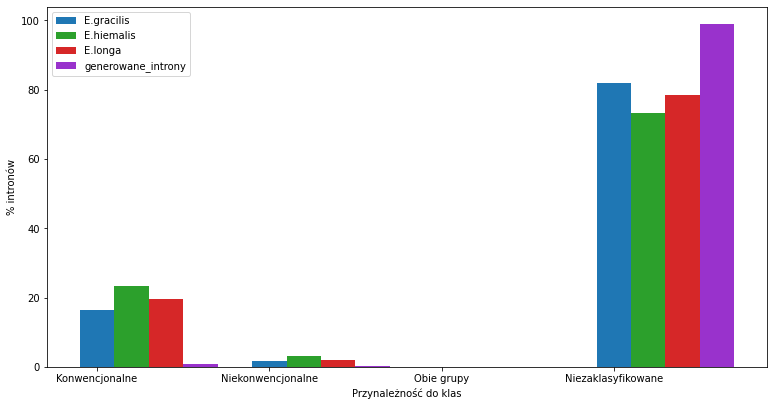

'with open(path+nazwa_pliku_png+\'_%s.csv\' %definiowanie, \'w\') as f:\n    writer = csv.writer(f)\n    header = ["gatunek"]+list(labels)+["Suma"]\n    writer.writerow(header)\n    writer.writerows(counts)\n    \nwith open(path+nazwa_pliku_png+\'_%s_wartosci.csv\' %definiowanie, \'w\') as f:\n    writer = csv.writer(f)\n    header = ["gatunek"]+list(labels)+["Suma"]\n    writer.writerow(header)\n    writer.writerows(dane_liczbowe)'

In [49]:
gat=["wszystkie_introny_wersje_E.gracilis_25zmarginesami.fasta", "wszystkie_introny_wersje_E.hiemalis_25zmarginesami.fasta", "wszystkie_introny_wersje_E.longa_25zmarginesami.fasta"]
sztuczne=["generowane_introny_0.fasta", "generowane_introny_1.fasta", "generowane_introny_2.fasta", "generowane_introny_3.fasta", "generowane_introny_4.fasta"]
definiowanie="struct"#"seq"
do_tytulu="struktury" if definiowanie=="struct" else "sekwencji"
path="/home/semik/projekty/noncanonical_introns/fasty_i_dbn/"
counts, dane_liczbowe, nazwa_pliku_png = count_nconv(gat+sztuczne, definiowanie, path=path)
mean_list=mean_generowanych(counts)

colors = ['tab:blue', 'tab:green', 'tab:red', 'darkorchid']#, 'magenta', 'mediumorchid', 'fuchsia', 'darkviolet']
labels=('Konwencjonalne','Niekonwencjonalne', 'Obie grupy','Niezaklasyfikowane')
wykres_licznosci(counts[:3]+[mean_list], colors, "Liczby wszystkich intronów z niekonwencjonalnymi rozpoznawanymi na podst. "+do_tytulu, x_labels=labels, definiowanie=definiowanie, path=path, \
                nazwa_pliku_png = nazwa_pliku_png)

'''with open(path+nazwa_pliku_png+'_%s.csv' %definiowanie, 'w') as f:
    writer = csv.writer(f)
    header = ["gatunek"]+list(labels)+["Suma"]
    writer.writerow(header)
    writer.writerows(counts)
    
with open(path+nazwa_pliku_png+'_%s_wartosci.csv' %definiowanie, 'w') as f:
    writer = csv.writer(f)
    header = ["gatunek"]+list(labels)+["Suma"]
    writer.writerow(header)
    writer.writerows(dane_liczbowe)'''

['E.gracilis', 0.020811196706069863, 0.06601142249966795, 0.02450524638066144, 0.10580754416257139, 0.06299807411342807, 0.012476756541373356, 0.13804124053659184, 0.48425255678044893, 0.08509596227918714, 120464] 1.0
['E.hiemalis', 0.02531068889287208, 0.07995011053354843, 0.030687996654119615, 0.10963733046543586, 0.0729297365119197, 0.015833183963673298, 0.1547245623468961, 0.4351586305789568, 0.07576776005257813, 133896] 1.0
['E.longa', 0.022746390018225152, 0.05534137109210711, 0.028003645030141595, 0.09421000981354269, 0.05583204822655264, 0.013423524463759988, 0.1546333940838357, 0.4725921772045423, 0.10321744006729286, 28532] 1.0
['generowane_introny_0', 0.00023449407902450463, 0.00035174111853675694, 0.0024621878297572987, 0.0032829171063430648, 0.0019931996717082894, 0.002579434869269551, 0.008324539805369914, 0.15077969281275647, 0.8299917927072341, 8529] 1.0
['generowane_introny_1', 0.0003478664192949907, 0.0003478664192949907, 0.002319109461966605, 0.003826530612244898, 0.

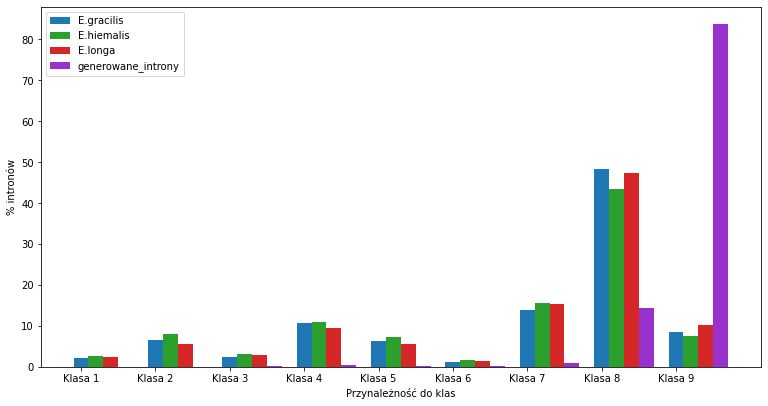

In [27]:
gat_counts_classes = count_nconv_classes(gat, path=path)
generowane_counts_classes = [mean_generowanych(count_nconv_classes(sztuczne, path=path))]


data, colors = gat_counts_classes+generowane_counts_classes, ['tab:blue', 'tab:green', 'tab:red', 'darkorchid']#, 'magenta', 'mediumorchid', 'fuchsia', 'darkviolet']
labels=tuple(["Klasa "+str(x) for x in range(1,10)])
wykres_licznosci(data, colors, "Liczby intronów w klasach niekonwencjonalnych", x_labels=labels, definiowanie="w_klasach_niekonwencjonalnych", path=path)
with open(path+'liczby_intronow_w_klasach_niekonwencjonalnych.csv', 'w') as f:
    writer = csv.writer(f)
    header = ["Gatunek"]+list(labels)+["Suma"]
    writer.writerow(header)
    writer.writerows(data)

['E.gracilis', 0.0466679802198119, 0.26067462167266575, 0.4965759514049412, 0.07445443492385397, 0.0032053900531989026, 0.01731006742372181, 0.05293458985904934, 0.04817696444275712, 208087] 0.9999999999999999
['E.hiemalis', 0.050378483179671224, 0.2700327950003094, 0.4906152672070623, 0.05736031186188974, 0.004264381329538189, 0.01849617391663057, 0.06037683311676258, 0.04847575438813605, 193932] 1.0
['E.longa', 0.055915675553801926, 0.2686620446047761, 0.4896755162241888, 0.07979632865490484, 0.0031565300715855928, 0.014148018713713996, 0.047479473160099955, 0.04116641301692877, 53223] 0.9999999999999999
['generowane_introny_0', 0.00038319070123898327, 0.007408353557287009, 0.12121599182526505, 0.36581938944948267, 0.0007663814024779665, 0.007536083791033338, 0.1191723080853238, 0.37769830118789116, 7829] 0.9999999999999999
['generowane_introny_1', 0.00025552574421873004, 0.009071163919764917, 0.11920275967803756, 0.37460074102465823, 0.0006388143605468251, 0.009326689663983647, 0.11

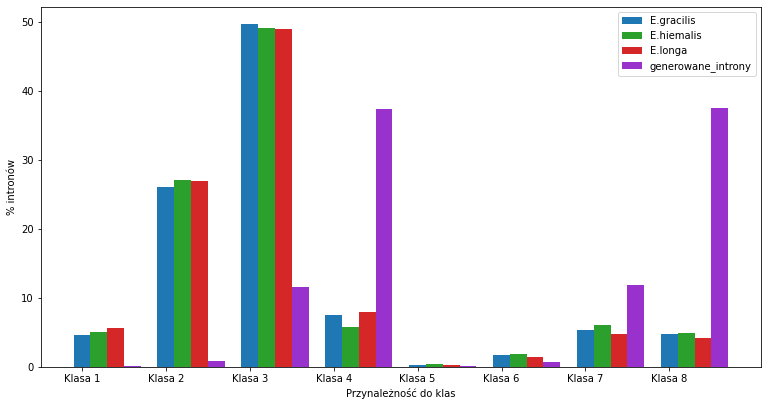

In [26]:
gat_counts_classes = count_nconv_classes(gat, path=path, conv=True)
generowane_counts_classes = [mean_generowanych(count_nconv_classes(sztuczne, path=path, conv=True))]


data, colors = gat_counts_classes+generowane_counts_classes, ['tab:blue', 'tab:green', 'tab:red', 'darkorchid']#, 'magenta', 'mediumorchid', 'fuchsia', 'darkviolet']
labels=tuple(["Klasa "+str(x) for x in range(1,9)])
wykres_licznosci(data, colors, "Liczby intronów w klasach konwencjonalnych", x_labels=labels, definiowanie="w_klasach_konwencjonalnych", path=path)
with open(path+'liczby_intronow_w_klasach_konwencjonalnych.csv', 'w') as f:
    writer = csv.writer(f)
    header = ["Gatunek"]+list(labels)+["Suma"]
    writer.writerow(header)
    writer.writerows(data)

['E.gracilis', 0.01719706221178229, 1734366]
['E.hiemalis', 0.032286075911617425, 1140089]
['E.longa', 0.02019388905622356, 375163]
['generowane_introny_0', 0.002253, 1000000]
['generowane_introny_1', 0.002303, 1000000]
['generowane_introny_2', 0.002159, 1000000]
['generowane_introny_3', 0.002263, 1000000]
['generowane_introny_4', 0.002207, 1000000]
['E.gracilis', 29826, 1734366]
['E.hiemalis', 36809, 1140089]
['E.longa', 7576, 375163]
['generowane_introny_0', 2253, 1000000]
['generowane_introny_1', 2303, 1000000]
['generowane_introny_2', 2159, 1000000]
['generowane_introny_3', 2263, 1000000]
['generowane_introny_4', 2207, 1000000]
[['E.gracilis', 0.01719706221178229, 1734366], ['E.hiemalis', 0.032286075911617425, 1140089], ['E.longa', 0.02019388905622356, 375163], ['generowane_introny', 0.002237, 1000000.0]]
['E.gracilis', 'E.hiemalis', 'E.longa', 'generowane_introny'] [1.7197062211782288, 3.2286075911617425, 2.019388905622356, 0.22369999999999998]


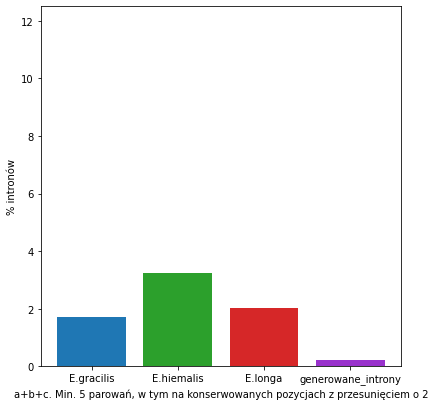

'with open(path+nazwa_pliku_png+\'.csv\', \'w\') as f:\n    writer = csv.writer(f)\n    header = ["gatunek"]+list(labels)+["Suma"]\n    writer.writerow(header)\n    writer.writerows(ulamki)\n    \nwith open(path+nazwa_pliku_png+\'_wartosci.csv\', \'w\') as f:\n    writer = csv.writer(f)\n    header = ["gatunek"]+list(labels)+["Suma"]\n    writer.writerow(header)\n    writer.writerows(dane_liczbowe)'

In [51]:
def wykres_licznosci_maly(counts, colors, podpis, definiowanie, path="", nazwa_pliku_png="liczby_intronow"):
    nazwa_pliku_png = nazwa_pliku_png + "_%s.png" %definiowanie
    print(counts)
    data=[l[1]*100  for l in counts]
    labels=[i[0] for i in counts]
    print(labels, data)
    
    fig = plt.figure(figsize=(5,5))
    ax = fig.add_axes([0,0,1,1])
    
    ax.bar(x=labels, height=data,color=colors)
    ax.set_xlabel(podpis)
    ax.set_ylabel('% intronów')
    plt.ylim([0,12.5])
    plt.show()
    #fig.savefig(path+nazwa_pliku_png , bbox_inches='tight')

def count_nconv_kilkawersji(listaplikow, definicja_nonconv="seq", path=""):
    ulamki=[]
    dane_liczbowe=[]
    for plik in listaplikow:
    
        if plik.startswith("wszystkie_introny_wersje_E."):
            name=plik.split("_")[3]
        elif plik.startswith("generowane_introny_"):
            name=plik.split(".")[0]
        else:
            print("zla nazwa pliku")
            break
        
        plik=".".join(plik.split(".")[:-1])
        plikfasta, plikdbn=plik+".fasta", plik+".dbn"
        fasta=open(path+plikfasta, 'r').readlines()
        if fasta[0][0]==";": fasta=fasta[2:]
        dbn = open(path+plikdbn, 'r').readlines()
        
        fasta = [ x+y for x,y in zip(fasta[0::2], fasta[1::2]) ]
        dbn = [x+y+z for x,y,z in zip(dbn[0::3], dbn[1::3], dbn[2::3])]
        
        l=len(fasta) if len(fasta)==len(dbn) else None
        
        global conv_count, nconv_count, both_count, all_count, non_count
        conv_count, nconv_count, both_count, all_count, non_count = 0,0,0,0,0
        prev_var = [0, False, False] #wersja, konwencjonalny, niekonwencjonalny struktur

        def dodaj(prev_var):
            global conv_count, nconv_count, both_count, all_count, non_count
            var, conv_ver, nonconv_str=prev_var
            all_count+=1

            if nonconv_str and conv_ver: both_count+=1
            elif nonconv_str and not conv_ver: nconv_count+=1
            elif not nonconv_str and conv_ver: conv_count+=1
            else: non_count+=1
            
        for i in range(l):
            f, d = fasta[i].split("\n"), dbn[i].split("\n")
            if f[1] != d[1].replace("U", "T"):
                print("zle sekwencje")
                break
            
            var,conv_ver = f[0].split(";")[2:4]
            var=int(var)
            conv_ver=int(conv_ver)
            vienna = d[2].split(" ")[0]
            seq=d[1]
            
            if definicja_nonconv=="struct":
                '''warunki na niekonwencjonalne'''
                nonconv_str=0
                nazwa_pliku_png = "test_parowaniakons_przesuniecieo2_Ypoczkon"
                if not '(' in vienna[-25:-5] and not ')' in vienna[5:25]:
                    #if vienna.count('(', 0, 25)>5:
                    #    nonconv_str = 2
                    #    if seq[-5] in ["G", "A"]:
                    #        nonconv_str = 1
                    parowania_kons = vienna[8:11]=="(((" and vienna[-13:-10]==")))" #pozycje 4,5,6 (-8,-7,-6) -> indeksy 3,4,5 (-8,-7,-6) -> z 5 nt eksonu 8,9,10 (-13,-12,-11)
                    parowan_5 = vienna.count('(', 0, 25)>=5
                    przesuniecie = vienna[:8].count("(") == vienna[-10:].count(")")
                    puryna_pocz = seq[5] in ["G", "A"]
                    puryna_koniec =  seq[-5] in ["G", "A"]
                    pirymidyna_pocz = seq[4] in ["U", "C", "T"]
                    pirymidyna_koniec = seq[-4] in ["U", "C", "T"]
                    
                    zestaw_zasad = [parowania_kons, przesuniecie, pirymidyna_koniec, pirymidyna_pocz]
                    if False not in zestaw_zasad:
                        nonconv_str = 1
                    #nazwa_pliku_png = ''
                '''warunki na niekonwencjonalne'''

            if var and var>prev_var[0]:
                if conv_ver>0: prev_var[1] = True
                if nonconv_str>0: prev_var[2] = True
                prev_var[0]=var
            elif not var:
                dodaj(prev_var)
                prev_var=[0,bool(conv_ver),bool(nonconv_str)]
        ulamki.append([name, nconv_count/all_count, all_count])
        dane_liczbowe.append([name, nconv_count, all_count])
    for count in ulamki:
        print(count)
    for i in dane_liczbowe:
        print(i)        
    return ulamki, dane_liczbowe, nazwa_pliku_png

gat=["wszystkie_introny_wersje_E.gracilis_25zmarginesami.fasta", "wszystkie_introny_wersje_E.hiemalis_25zmarginesami.fasta", "wszystkie_introny_wersje_E.longa_25zmarginesami.fasta"]
sztuczne=["generowane_introny_0.fasta", "generowane_introny_1.fasta", "generowane_introny_2.fasta", "generowane_introny_3.fasta", "generowane_introny_4.fasta"]
definiowanie="struct"#"seq"
path="/home/semik/projekty/noncanonical_introns/fasty_i_dbn/"
ulamki, dane_liczbowe, nazwa_pliku_png = count_nconv_kilkawersji(gat+sztuczne, definiowanie, path=path)
nazwa_pliku_png="malewykresy/"+nazwa_pliku_png
mean_list=mean_generowanych(ulamki)

colors = ['tab:blue', 'tab:green', 'tab:red', 'darkorchid']#, 'magenta', 'mediumorchid', 'fuchsia', 'darkviolet']
podpis="a+b+c. Min. 5 parowań, w tym na konserwowanych pozycjach z przesunięciem o 2"
wykres_licznosci_maly(ulamki[:3]+[mean_list], colors, podpis, definiowanie=definiowanie, path=path, nazwa_pliku_png = nazwa_pliku_png)

'''with open(path+nazwa_pliku_png+'.csv', 'w') as f:
    writer = csv.writer(f)
    header = ["gatunek"]+list(labels)+["Suma"]
    writer.writerow(header)
    writer.writerows(ulamki)
    
with open(path+nazwa_pliku_png+'_wartosci.csv', 'w') as f:
    writer = csv.writer(f)
    header = ["gatunek"]+list(labels)+["Suma"]
    writer.writerow(header)
    writer.writerows(dane_liczbowe)'''